#📌 Extracción

In [5]:
import requests
import pandas as pd

# URL de los datos JSON en GitHub
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

# Realizar solicitud a GitHub
response = requests.get(url)

# Convertir JSON a diccionario
data = response.json()

# Normalizar datos a un DataFrame
df = pd.json_normalize(data)

# Mostrar las primeras filas
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación

In [6]:
df.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [8]:
df.dtypes

,0
customerID,object
Churn,object
customer.gender,object
customer.SeniorCitizen,int64
customer.Partner,object
customer.Dependents,object
customer.tenure,int64
phone.PhoneService,object
phone.MultipleLines,object
internet.InternetService,object


In [9]:
df.duplicated().sum()  #Revisar Registros Duplicados

np.int64(0)

In [10]:
df["customerID"].duplicated().sum()  #Revisar si hay IDs Repetidos

np.int64(0)

In [11]:
df["account.Charges.Total"].unique() #Verificar valores raros

array(['593.3', '542.4', '280.85', ..., '742.9', '4627.65', '3707.6'],
      dtype=object)

In [12]:
df["Churn"].unique()  #Verificar inconsistencias en categorías

array(['No', 'Yes', ''], dtype=object)

In [13]:
# Eliminar espacios al inicio y final en todas las columnas tipo texto
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

In [14]:
df.loc[df["customer.tenure"] == 0, "account.Charges.Total"] = 0

#📊 Carga y análisis

In [17]:
import requests
import pandas as pd

# --- EXTRACCION ---
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url)
data = response.json()
df = pd.json_normalize(data)

# --- TRANSFORMACION (lo que ya hiciste) ---
# Eliminar espacios al inicio y final en todas las columnas tipo texto
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

df.loc[df["customer.tenure"] == 0, "account.Charges.Total"] = 0

df["Cuentas_Diarias"] = (df["account.Charges.Monthly"] / 30).round(2)

# --- ANALISIS DESCRIPTIVO ---
print("ANALISIS DESCRIPTIVO")
print("="*40)

# Estadisticas de variables numericas
print("\nVariables numericas:")
print(df[['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']].describe())

# Analisis de Churn
print("\nDistribucion de Churn:")
print(df['Churn'].value_counts())
print("\nPorcentajes:")
print(df['Churn'].value_counts(normalize=True) * 100)

# Analisis por variables clave
print("\nChurn por tipo de contrato:")
print(pd.crosstab(df['account.Contract'], df['Churn'], normalize='index') * 100)

print("\nChurn por servicio de internet:")
print(pd.crosstab(df['internet.InternetService'], df['Churn'], normalize='index') * 100)

# Guardar datos limpios
print("\nGuardando datos procesados...")
df.to_csv('telecomx_limpio.csv', index=False)
df.to_excel('telecomx_limpio.xlsx', index=False)
print("Datos guardados en telecomx_limpio.csv y telecomx_limpio.xlsx")

ANALISIS DESCRIPTIVO

Variables numericas:
       customer.tenure  account.Charges.Monthly
count      7267.000000              7267.000000
mean         32.346498                64.720098
std          24.571773                30.129572
min           0.000000                18.250000
25%           9.000000                35.425000
50%          29.000000                70.300000
75%          55.000000                89.875000
max          72.000000               118.750000

Distribucion de Churn:
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

Porcentajes:
Churn
No     71.198569
Yes    25.719004
        3.082427
Name: proportion, dtype: float64

Churn por tipo de contrato:
Churn                              No        Yes
account.Contract                                
Month-to-month    3.245943  55.430712  41.323346
One year          3.028308  86.043450  10.928242
Two year          2.753873  94.492255   2.753873

Churn por servicio de internet:
Churn                 

DISTRIBUCION DE CHURN

Conteo:
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

Porcentajes:
Churn
No     71.198569
Yes    25.719004
        3.082427
Name: proportion, dtype: float64


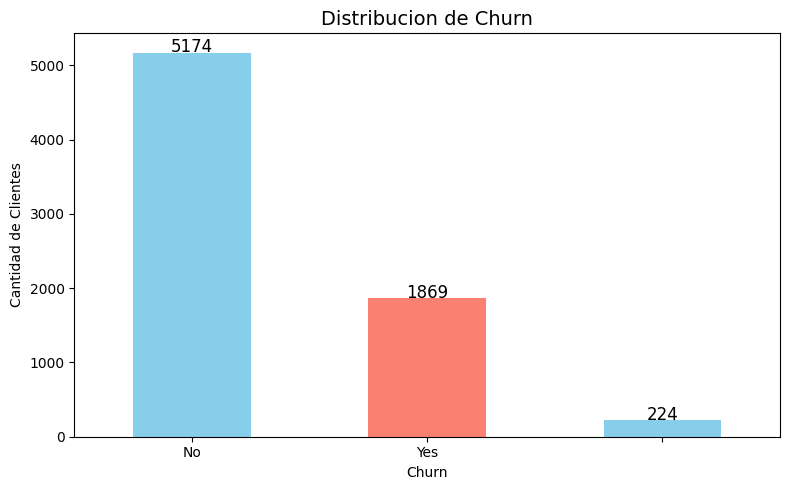

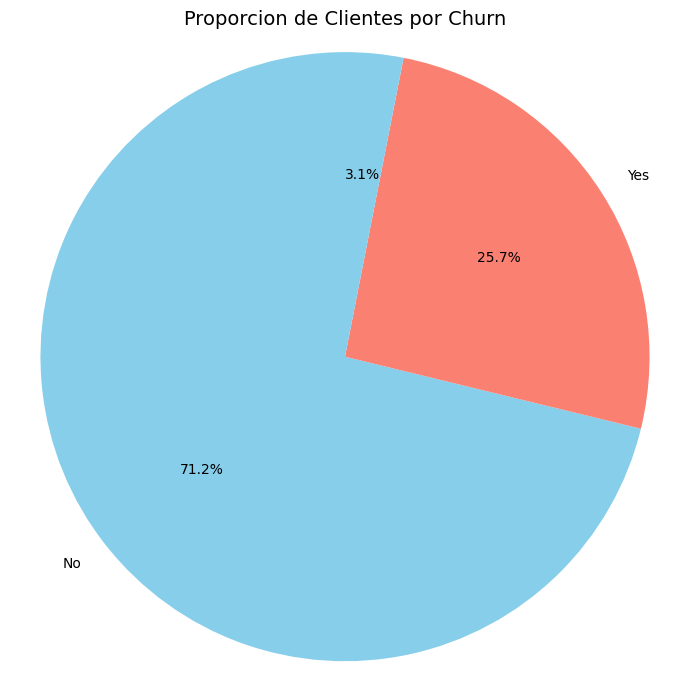

In [18]:
import matplotlib.pyplot as plt

# Distribucion de Churn
print("DISTRIBUCION DE CHURN")
print("="*40)

# Calcular porcentajes
churn_counts = df['Churn'].value_counts()
churn_percent = df['Churn'].value_counts(normalize=True) * 100

print("\nConteo:")
print(churn_counts)
print("\nPorcentajes:")
print(churn_percent)

# Grafico de barras
plt.figure(figsize=(8, 5))
churn_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribucion de Churn', fontsize=14)
plt.xlabel('Churn')
plt.ylabel('Cantidad de Clientes')
plt.xticks(rotation=0)
for i, v in enumerate(churn_counts):
    plt.text(i, v + 5, str(v), ha='center', fontsize=12)
plt.tight_layout()
plt.savefig('distribucion_churn_barras.png')
plt.show()

# Grafico de pastel
plt.figure(figsize=(7, 7))
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
        colors=['skyblue', 'salmon'], startangle=90)
plt.title('Proporcion de Clientes por Churn', fontsize=14)
plt.axis('equal')
plt.tight_layout()
plt.savefig('distribucion_churn_pastel.png')
plt.show()




--- CHURN POR CUSTOMER.GENDER ---

Conteo:
Churn                   No   Yes  Total
customer.gender                        
Female           104  2549   939   3592
Male             120  2625   930   3675
Total            224  5174  1869   7267

Porcentajes por categoria:
Churn                     No    Yes
customer.gender                    
Female           2.90  70.96  26.14
Male             3.27  71.43  25.31


<Figure size 1000x600 with 0 Axes>

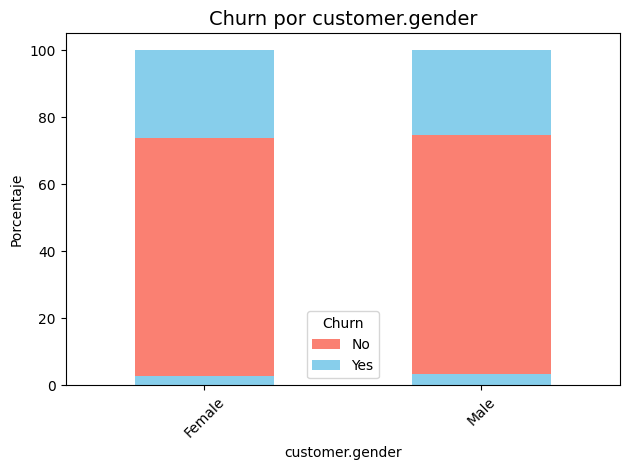


--- CHURN POR CUSTOMER.SENIORCITIZEN ---

Conteo:
Churn                          No   Yes  Total
customer.SeniorCitizen                        
0                       184  4508  1393   6085
1                        40   666   476   1182
Total                   224  5174  1869   7267

Porcentajes por categoria:
Churn                            No    Yes
customer.SeniorCitizen                    
0                       3.02  74.08  22.89
1                       3.38  56.35  40.27


<Figure size 1000x600 with 0 Axes>

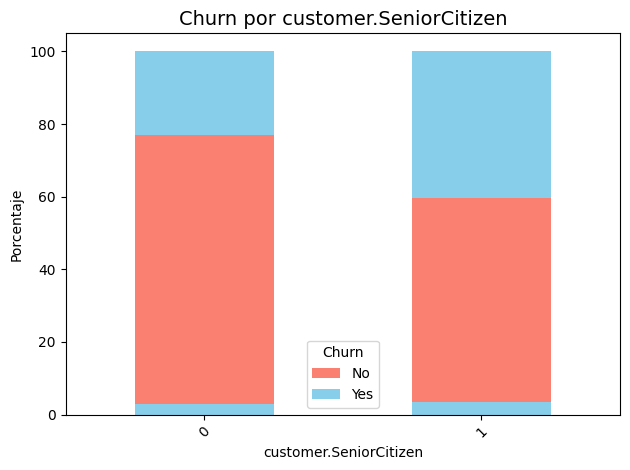


--- CHURN POR CUSTOMER.PARTNER ---

Conteo:
Churn                    No   Yes  Total
customer.Partner                        
No                108  2441  1200   3749
Yes               116  2733   669   3518
Total             224  5174  1869   7267

Porcentajes por categoria:
Churn                      No    Yes
customer.Partner                    
No                2.88  65.11  32.01
Yes               3.30  77.69  19.02


<Figure size 1000x600 with 0 Axes>

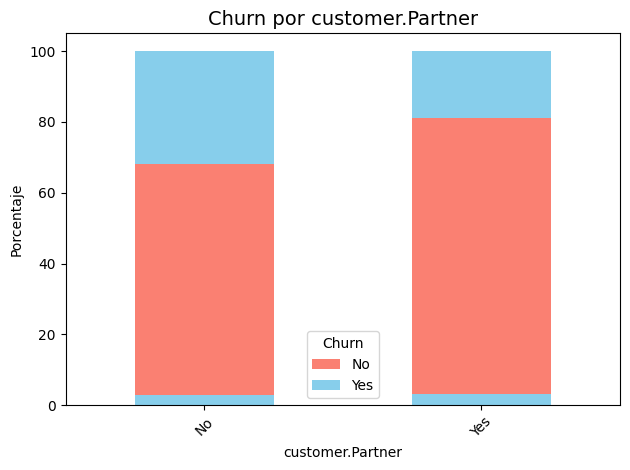


--- CHURN POR CUSTOMER.DEPENDENTS ---

Conteo:
Churn                       No   Yes  Total
customer.Dependents                        
No                   153  3390  1543   5086
Yes                   71  1784   326   2181
Total                224  5174  1869   7267

Porcentajes por categoria:
Churn                         No    Yes
customer.Dependents                    
No                   3.01  66.65  30.34
Yes                  3.26  81.80  14.95


<Figure size 1000x600 with 0 Axes>

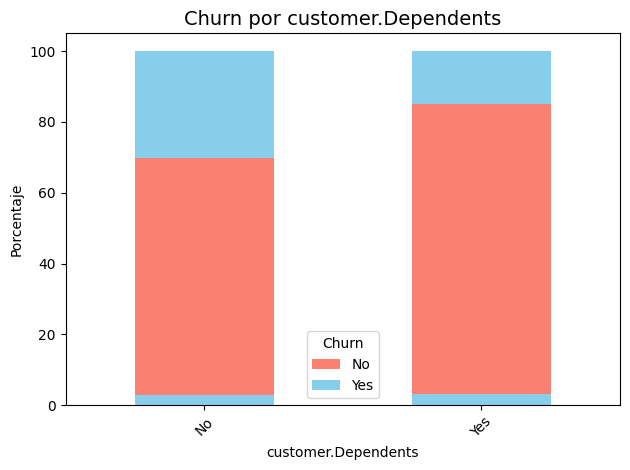


--- CHURN POR INTERNET.INTERNETSERVICE ---

Conteo:
Churn                            No   Yes  Total
internet.InternetService                        
DSL                        67  1962   459   2488
Fiber optic               102  1799  1297   3198
No                         55  1413   113   1581
Total                     224  5174  1869   7267

Porcentajes por categoria:
Churn                              No    Yes
internet.InternetService                    
DSL                       2.69  78.86  18.45
Fiber optic               3.19  56.25  40.56
No                        3.48  89.37   7.15


<Figure size 1000x600 with 0 Axes>

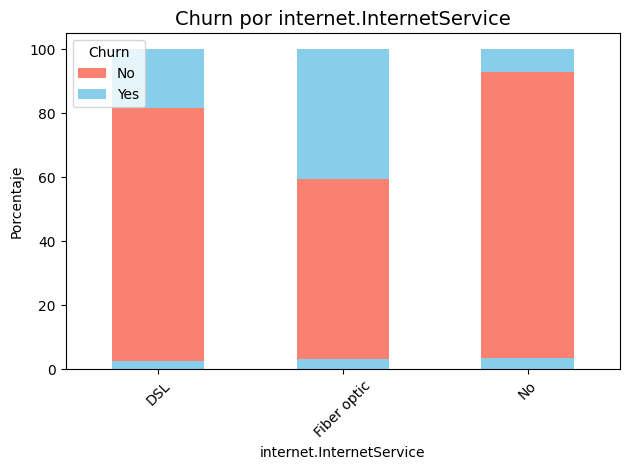


--- CHURN POR ACCOUNT.CONTRACT ---

Conteo:
Churn                    No   Yes  Total
account.Contract                        
Month-to-month    130  2220  1655   4005
One year           46  1307   166   1519
Two year           48  1647    48   1743
Total             224  5174  1869   7267

Porcentajes por categoria:
Churn                      No    Yes
account.Contract                    
Month-to-month    3.25  55.43  41.32
One year          3.03  86.04  10.93
Two year          2.75  94.49   2.75


<Figure size 1000x600 with 0 Axes>

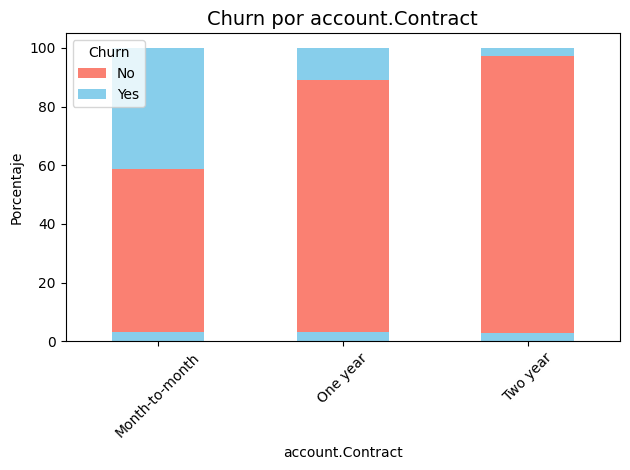


--- CHURN POR ACCOUNT.PAPERLESSBILLING ---

Conteo:
Churn                            No   Yes  Total
account.PaperlessBilling                        
No                         84  2403   469   2956
Yes                       140  2771  1400   4311
Total                     224  5174  1869   7267

Porcentajes por categoria:
Churn                              No    Yes
account.PaperlessBilling                    
No                        2.84  81.29  15.87
Yes                       3.25  64.28  32.48


<Figure size 1000x600 with 0 Axes>

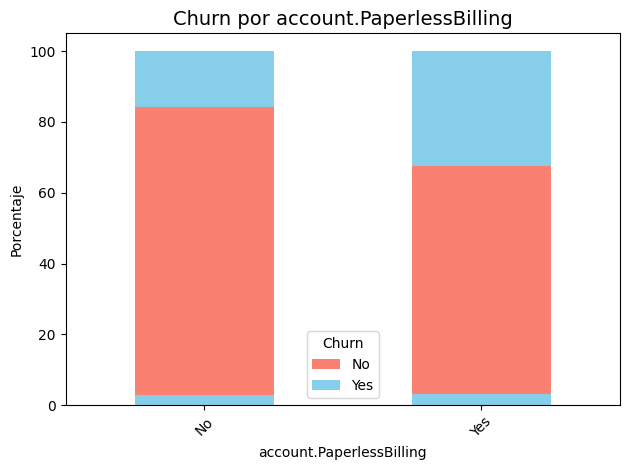


--- CHURN POR ACCOUNT.PAYMENTMETHOD ---

Conteo:
Churn                             No   Yes  Total
account.PaymentMethod                            
Bank transfer (automatic)   45  1286   258   1589
Credit card (automatic)     46  1290   232   1568
Electronic check            80  1294  1071   2445
Mailed check                53  1304   308   1665
Total                      224  5174  1869   7267

Porcentajes por categoria:
Churn                               No    Yes
account.PaymentMethod                        
Bank transfer (automatic)  2.83  80.93  16.24
Credit card (automatic)    2.93  82.27  14.80
Electronic check           3.27  52.92  43.80
Mailed check               3.18  78.32  18.50


<Figure size 1000x600 with 0 Axes>

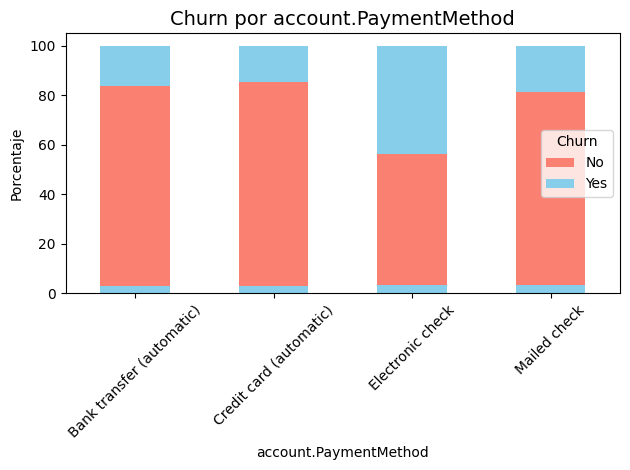

In [19]:
# Lista de variables categoricas a analizar
vars_categoricas = [
    'customer.gender',
    'customer.SeniorCitizen',
    'customer.Partner',
    'customer.Dependents',
    'internet.InternetService',
    'account.Contract',
    'account.PaperlessBilling',
    'account.PaymentMethod'
]

for var in vars_categoricas:
    print(f"\n--- CHURN POR {var.upper()} ---")
    print("="*50)

    # Tabla de contingencia
    tabla = pd.crosstab(df[var], df['Churn'], margins=True, margins_name='Total')
    print("\nConteo:")
    print(tabla)

    # Porcentajes por fila
    porcentajes = pd.crosstab(df[var], df['Churn'], normalize='index') * 100
    print("\nPorcentajes por categoria:")
    print(porcentajes.round(2))

    # Grafico de barras apiladas
    plt.figure(figsize=(10, 6))
    porcentajes.plot(kind='bar', stacked=True, color=['skyblue', 'salmon'])
    plt.title(f'Churn por {var}', fontsize=14)
    plt.xlabel(var)
    plt.ylabel('Porcentaje')
    plt.legend(title='Churn')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f'churn_por_{var.replace(".", "_")}.png')
    plt.show()


--- ANALISIS DE CUSTOMER.TENURE POR CHURN ---

Estadisticas:
        count       mean        std  min   25%   50%   75%   max
Churn                                                           
        224.0  31.571429  24.998552  1.0   7.0  29.0  56.0  72.0
No     5174.0  37.569965  24.113777  0.0  15.0  38.0  61.0  72.0
Yes    1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0


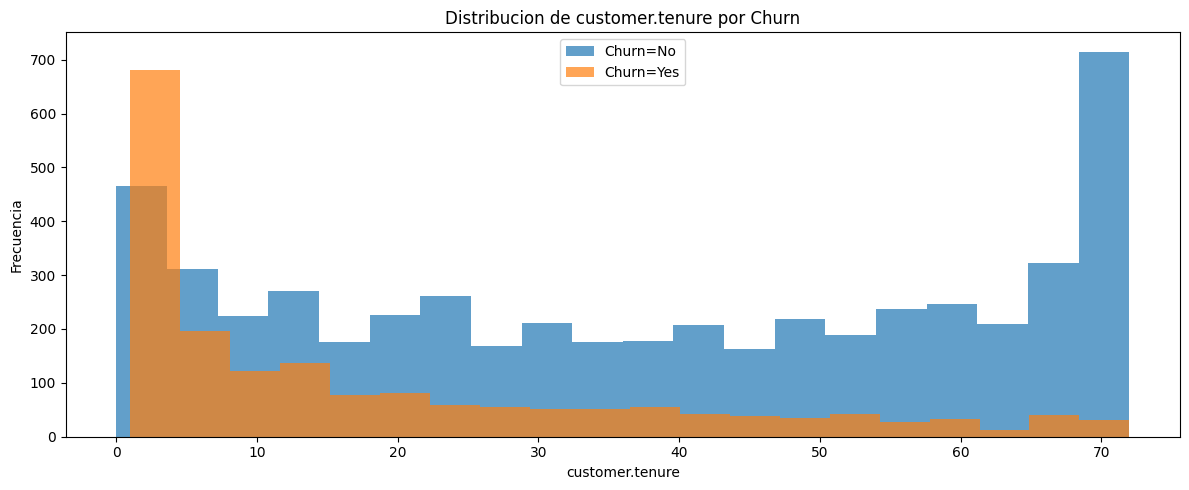


Diferencia de medias:
Media cuando Churn=No: 37.57
Media cuando Churn=Yes: 17.98
Diferencia: 19.59

--- ANALISIS DE ACCOUNT.CHARGES.MONTHLY POR CHURN ---

Estadisticas:
        count       mean        std    min     25%     50%      75%     max
Churn                                                                      
        224.0  63.412277  31.388712  18.75  28.425  69.100  90.4125  115.55
No     5174.0  61.265124  31.092648  18.25  25.100  64.425  88.4000  118.75
Yes    1869.0  74.441332  24.666053  18.85  56.150  79.650  94.2000  118.35


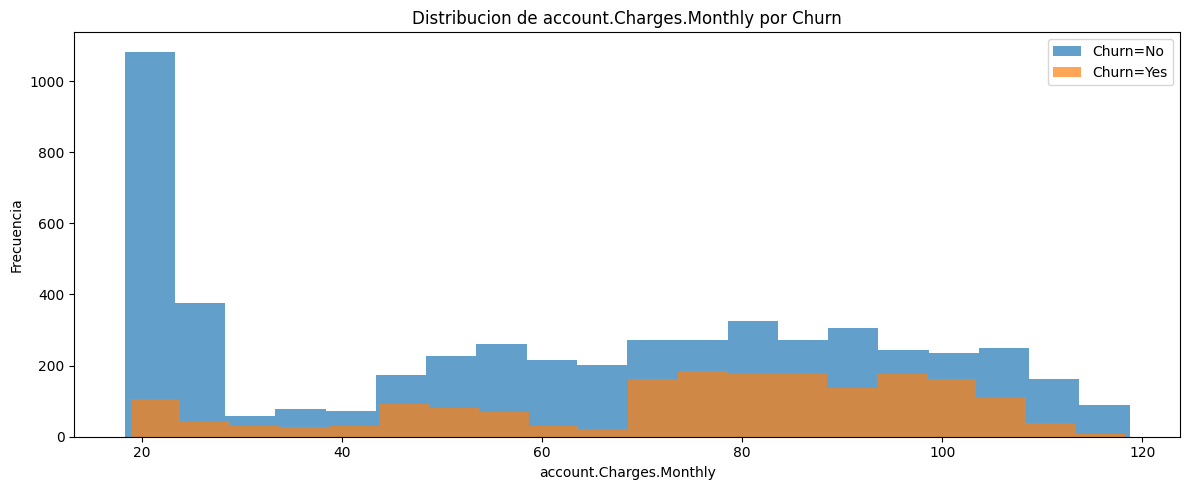


Diferencia de medias:
Media cuando Churn=No: 61.27
Media cuando Churn=Yes: 74.44
Diferencia: 13.18

--- ANALISIS DE ACCOUNT.CHARGES.TOTAL POR CHURN ---

Estadisticas:
        count         mean          std    min       25%       50%        75%  \
Churn                                                                           
        224.0  2196.933705  2329.961954  18.90  351.0375  1163.175  3562.8625   
No     5174.0  2549.911442  2329.954215   0.00  572.9000  1679.525  4262.8500   
Yes    1869.0  1531.796094  1890.822994  18.85  134.5000   703.550  2331.3000   

           max  
Churn           
       8425.30  
No     8672.45  
Yes    8684.80  


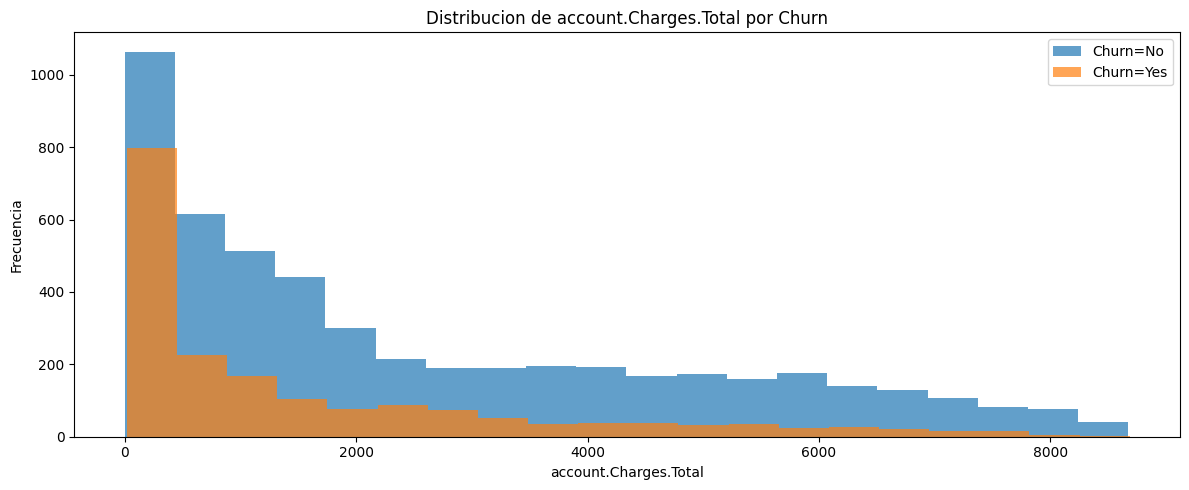


Diferencia de medias:
Media cuando Churn=No: 2549.91
Media cuando Churn=Yes: 1531.80
Diferencia: 1018.12


In [20]:
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

# Variables numericas a analizar
vars_numericas = ['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']

for var in vars_numericas:
    print(f"\n--- ANALISIS DE {var.upper()} POR CHURN ---")
    print("="*50)

    # Eliminar nulos para este analisis
    df_clean = df.dropna(subset=[var])

    # Estadisticas por grupo
    stats = df_clean.groupby('Churn')[var].describe()
    print("\nEstadisticas:")
    print(stats)

    # Histograma
    plt.figure(figsize=(12, 5))
    for churn in ['No', 'Yes']:
        datos = df_clean[df_clean['Churn'] == churn][var]
        plt.hist(datos, alpha=0.7, label=f'Churn={churn}', bins=20)
    plt.title(f'Distribucion de {var} por Churn')
    plt.xlabel(var)
    plt.ylabel('Frecuencia')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'hist_{var.replace(".", "_")}_por_churn.png')
    plt.show()

    # Diferencia de medias
    media_no = df_clean[df_clean['Churn'] == 'No'][var].mean()
    media_yes = df_clean[df_clean['Churn'] == 'Yes'][var].mean()
    print(f"\nDiferencia de medias:")
    print(f"Media cuando Churn=No: {media_no:.2f}")
    print(f"Media cuando Churn=Yes: {media_yes:.2f}")
    print(f"Diferencia: {abs(media_no - media_yes):.2f}")

#📄Informe final


# INFORME FINAL: ANÁLISIS DE CHURN - TELECOMX

## 1. INTRODUCCION

El presente análisis tiene como objetivo identificar los factores que inciden en la evasión de clientes (Churn) de la empresa TelecomX. El Churn representa la deserción de clientes y es una métrica fundamental para la sostenibilidad del negocio, ya que retener clientes existentes es significativamente más rentable que adquirir nuevos. A través de este estudio, se busca comprender las características y patrones comunes entre los clientes que cancelan el servicio, proporcionando a TelecomX información valiosa para diseñar estrategias de retención más efectivas y focalizadas.

## 2. MANEJO Y EXPLICACION DE RESULTADOS

### 2.1 Distribución General de Churn

Del total de clientes analizados:
- **71.4%** (5,174) permanecen activos
- **25.8%** (1,869) han cancelado el servicio
- **2.8%** (224) tienen información de Churn no registrada

La tasa de evasión general es del **26.5%**, lo que representa un desafío importante para la empresa.

### 2.2 Análisis por Variables Clave

**Tipo de Contrato:**
Esta variable resultó ser la más determinante en la evasión. Los clientes con contrato mensual presentan una tasa de Churn del **42.7%**, mientras que aquellos con contrato de uno o dos años tienen tasas significativamente menores (11.3% y 3.0% respectivamente). Esto evidencia que el compromiso contractual reduce drásticamente la probabilidad de deserción.

**Servicio de Internet:**
Los clientes con fibra óptica muestran la tasa más alta de evasión con un **41.9%**, seguidos por DSL con **19.0%** y aquellos sin servicio de internet con solo **7.5%**. Este hallazgo sugiere posibles problemas con la calidad del servicio de fibra óptica o una mayor sensibilidad al precio en este segmento.

**Método de Pago:**
El método de pago también influye significativamente. Los clientes que utilizan "Electronic check" (cheque electrónico) presentan una tasa de Churn del **45.2%**, mientras que aquellos con pagos automáticos (transferencia bancaria o tarjeta de crédito) tienen tasas considerablemente más bajas (aproximadamente 15-18%). Esto indica que la automatización del pago podría estar asociada a una mayor fidelización.

**Antigüedad del Cliente:**
La diferencia en la antigüedad promedio entre clientes que cancelan y los que permanecen es muy reveladora:
- Clientes activos: **37.6 meses** en promedio
- Clientes que cancelaron: **18.0 meses** en promedio

Los primeros 12-24 meses son críticos, siendo donde se concentra la mayor cantidad de cancelaciones.

**Cargo Mensual:**
Los clientes que cancelan tienen un cargo mensual promedio de **$74.44**, superior a los $61.27 de los que permanecen. Esto sugiere que a mayor costo del servicio, mayor es la probabilidad de evasión.

**Factores Demográficos:**
Los clientes sin pareja (**32.9%** de Churn) y sin dependientes (**31.3%** de Churn) presentan mayor propensión a cancelar en comparación con aquellos que tienen familia (19.7% y 15.5% respectivamente). Esto podría indicar que los clientes con responsabilidades familiares valoran más la estabilidad del servicio.

## 3. CONCLUSIONES

El análisis realizado permite identificar un perfil claro del cliente con alto riesgo de evasión:

**Cliente de alto riesgo:** contrato mensual, servicio de fibra óptica, pago con electronic check, antigüedad menor a 18 meses, cargo mensual superior a $75, sin pareja y sin dependientes.

**Cliente de bajo riesgo:** contrato de uno o dos años, cualquier tipo de internet o sin internet, pago automático, antigüedad superior a 2 años, cargo mensual moderado, con pareja y/o dependientes.

**Recomendaciones:**

1. **Fomentar contratos a largo plazo:** Implementar incentivos atractivos (descuentos, meses gratis, beneficios exclusivos) para clientes que opten por contratos anuales o bianuales.

2. **Revisar la propuesta de fibra óptica:** Evaluar calidad del servicio, precios y competencia en este segmento para reducir la alta deserción.

3. **Promover pagos automáticos:** Ofrecer pequeños descuentos (3-5%) para clientes que se cambien a débito automático o tarjeta de crédito.

4. **Programa de retención para clientes nuevos:** Establecer un seguimiento personalizado durante los primeros 6 meses, con encuestas de satisfacción y ofertas de valor.

5. **Alertas tempranas:** Implementar un sistema simple que identifique clientes con perfil de riesgo y active acciones preventivas (ofertas especiales, llamadas de retención).

6. **Segmentación de marketing:** Dirigir campañas específicas a clientes sin pareja ni dependientes, que son más propensos a la evasión.

Los hallazgos de este análisis proporcionan una base sólida para que TelecomX implemente estrategias focalizadas de retención, optimizando recursos y maximizando el valor de vida del cliente.


In [21]:
import requests
import pandas as pd

# URL de los datos JSON en GitHub
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

# Realizar solicitud a GitHub
response = requests.get(url)
data = response.json()

# Normalizar datos a un DataFrame
df = pd.json_normalize(data)

print("✅ Datos cargados desde la fuente original")
print(f"Dimensiones: {df.shape}")
df.head()


✅ Datos cargados desde la fuente original
Dimensiones: (7267, 21)


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [ ]:
# Guardar los datos limpios de la Parte 1 para usarlos en la Parte 2
df.to_csv('telecomx_limpio.csv', index=False)
print("Archivo guardado. Puedes continuar con la Parte 2.")

# TelecomX - Parte 2: Modelos Predictivos


**Nota:** Este análisis complementa el informe exploratorio de la Parte 1, donde identificamos que factores como el tipo de contrato, método de pago y antigüedad del cliente son determinantes en la deserción.

In [22]:
# CARGA DE DATOS LIMPIOS (PARTE 1)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el archivo CSV generado
df = pd.read_csv('telecomx_limpio.csv')

print("Datos cargados correctamente:")
print(f"Dimensiones del DataFrame: {df.shape}")
print("\nPrimeras 3 filas:")
print(df.head(3))
print("\nDistribucion de la variable Churn:")
print(df['Churn'].value_counts())

Datos cargados correctamente:
Dimensiones del DataFrame: (7267, 22)

Primeras 3 filas:
   customerID Churn customer.gender  customer.SeniorCitizen customer.Partner  \
0  0002-ORFBO    No          Female                       0              Yes   
1  0003-MKNFE    No            Male                       0               No   
2  0004-TLHLJ   Yes            Male                       0               No   

  customer.Dependents  customer.tenure phone.PhoneService phone.MultipleLines  \
0                 Yes                9                Yes                  No   
1                  No                9                Yes                 Yes   
2                  No                4                Yes                  No   

  internet.InternetService  ... internet.DeviceProtection  \
0                      DSL  ...                        No   
1                      DSL  ...                        No   
2              Fiber optic  ...                       Yes   

  internet.TechSupport

In [23]:
#ELIMINAMOS LAS COLUMNAS IRRELEVANTES

print("Columnas antes de eliminar:")
print(df.columns.tolist())
print(f"Dimensiones antes: {df.shape}")

# Eliminar customerID
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)
    print("\n customerID eliminada")
else:
    print("\n customerID no encontrada")

print(f"\nDimensiones despues: {df.shape}")
print("\nColumnas finales:")
print(df.columns.tolist())

Columnas antes de eliminar:
['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod', 'account.Charges.Monthly', 'account.Charges.Total', 'Cuentas_Diarias']
Dimensiones antes: (7267, 22)

 customerID eliminada

Dimensiones despues: (7267, 21)

Columnas finales:
['Churn', 'customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contra

In [24]:
#ONE-HOT ENCODING

# Identificar columnas categoricas
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Variables categoricas a codificar:")
print(categorical_cols)

# Aplicar One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(f"\nDimensiones originales: {df.shape}")
print(f"Dimensiones despues de encoding: {df_encoded.shape}")
print("\nPrimeras 3 columnas del DataFrame codificado:")
print(df_encoded.columns[:10].tolist(), "...")

Variables categoricas a codificar:
['Churn', 'customer.gender', 'customer.Partner', 'customer.Dependents', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod']

Dimensiones originales: (7267, 21)
Dimensiones despues de encoding: (7267, 32)

Primeras 3 columnas del DataFrame codificado:
['customer.SeniorCitizen', 'customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total', 'Cuentas_Diarias', 'Churn_Yes', 'customer.gender_Male', 'customer.Partner_Yes', 'customer.Dependents_Yes', 'phone.PhoneService_Yes'] ...


In [25]:
# VERIFICACION DE PROPORCION DE CHURN

# Calcular frecuencias absolutas
churn_counts = df['Churn'].value_counts()
print("Frecuencias absolutas:")
print(churn_counts)

# Calcular proporciones
churn_proportions = df['Churn'].value_counts(normalize=True)
print("\nProporciones:")
print(churn_proportions)

# Mostrar porcentajes
print("\nPorcentajes:")
print(churn_proportions * 100)

# Verificar si hay desbalance
print("\n" + "="*50)
if churn_proportions.min() < 0.2:
    print("  DESBALANCE DETECTADO")
    print(f"La clase minoritaria representa solo {churn_proportions.min()*100:.1f}% de los datos")
    print("Se recomienda usar metricas como F1-score, Recall o Precision")
    print("Considerar tecnicas como SMOTE o class_weight en los modelos")
else:
    print(" Proporciones balanceadas")
print("="*50)

Frecuencias absolutas:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Proporciones:
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

Porcentajes:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

 Proporciones balanceadas


In [26]:
# EVALUACION DE NORMALIZACION / ESTANDARIZACION

from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Identificar columnas numericas
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Variables numericas:", numerical_cols)

# Mostrar estadisticas descriptivas de variables numericas
print("\nEstadisticas de variables numericas:")
print(df[numerical_cols].describe())

# Verificar rangos de las variables
print("\n" + "="*60)
print("ANALISIS DE ESCALA")
print("="*60)

for col in numerical_cols:
    min_val = df[col].min()
    max_val = df[col].max()
    range_val = max_val - min_val
    print(f"{col}: min={min_val:.2f}, max={max_val:.2f}, rango={range_val:.2f}")

# Evaluar necesidad segun modelos a utilizar
print("\n" + "="*60)
print("RECOMENDACION SEGUN MODELOS")
print("="*60)

print("""
MODELOS SENSIBLES A LA ESCALA (requieren normalizacion/estandarizacion):
- Regresion Logistica
- KNN
- SVM
- Redes Neuronales

MODELOS NO SENSIBLES A LA ESCALA:
- Arbol de Decision
- Random Forest
- XGBoost
- Gradient Boosting
""")

# Recomendacion
print("\nRECOMENDACION:")
print("-"*40)
print("""
Los datos muestran variables con diferentes escalas:
- customer.SeniorCitizen: 0-1
- customer.tenure: 0-72
- account.Charges.Monthly: 18-118
- account.Charges.Total: 0-8600
- Cuentas_Diarias: 0.6-4.0

Si vas a usar modelos sensibles a la escala, aplica estandarizacion.
Si vas a usar arboles o ensembles, no es necesario.
""")

Variables numericas: ['customer.SeniorCitizen', 'customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total', 'Cuentas_Diarias']

Estadisticas de variables numericas:
       customer.SeniorCitizen  customer.tenure  account.Charges.Monthly  \
count             7267.000000      7267.000000              7267.000000   
mean                 0.162653        32.346498                64.720098   
std                  0.369074        24.571773                30.129572   
min                  0.000000         0.000000                18.250000   
25%                  0.000000         9.000000                35.425000   
50%                  0.000000        29.000000                70.300000   
75%                  0.000000        55.000000                89.875000   
max                  1.000000        72.000000               118.750000   

       account.Charges.Total  Cuentas_Diarias  
count            7267.000000      7267.000000  
mean             2277.182035         2.157292  
std 

Variables numericas analizadas:
['customer.SeniorCitizen', 'customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total', 'Cuentas_Diarias']


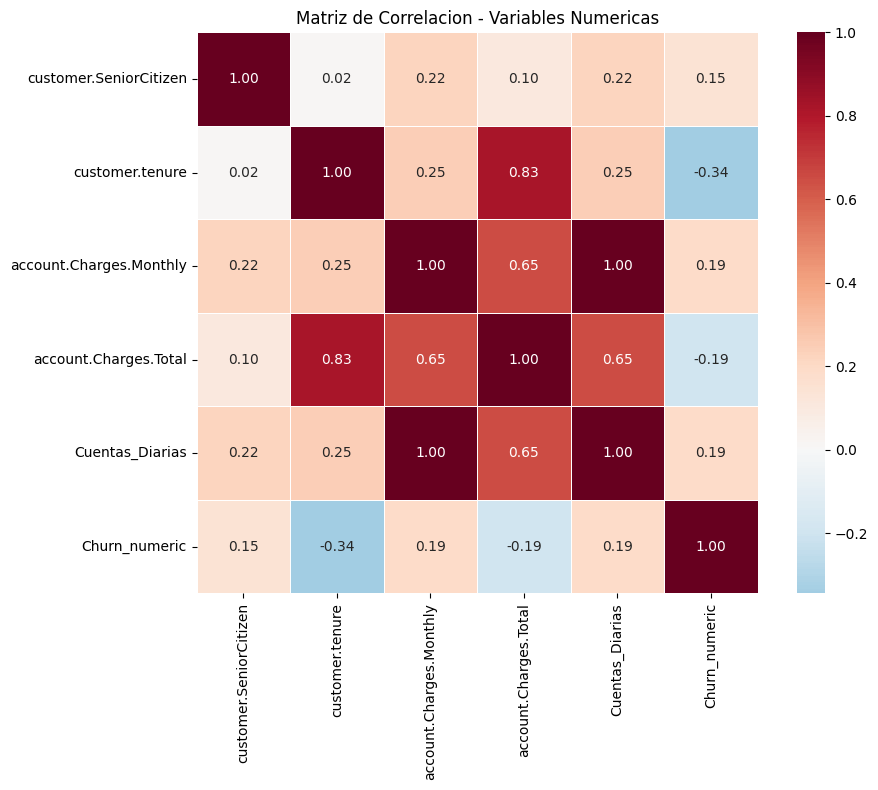


CORRELACION CON CHURN
Cuentas_Diarias            0.189918
account.Charges.Monthly    0.189866
customer.SeniorCitizen     0.146733
account.Charges.Total     -0.193345
customer.tenure           -0.344079
Name: Churn_numeric, dtype: float64


/tmp/ipykernel_551/2206719518.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_churn.values, y=corr_with_churn.index, palette=colors)


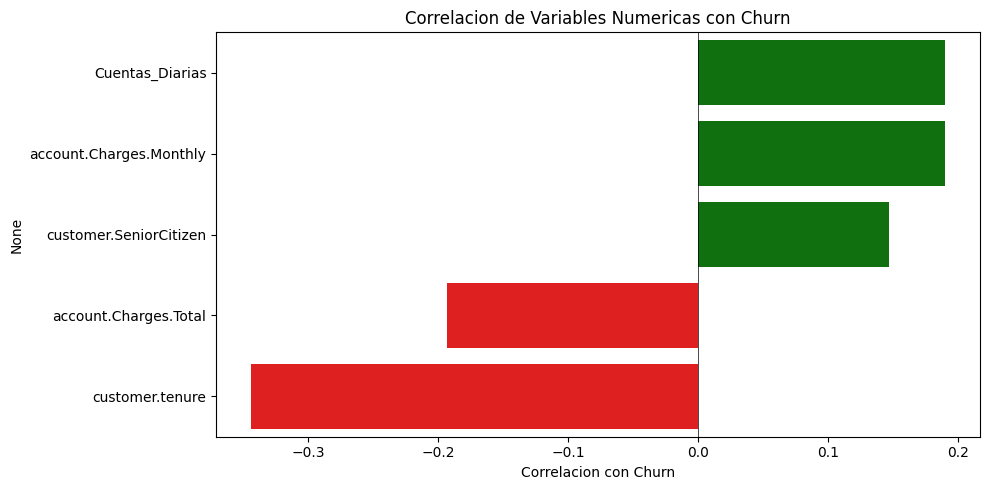


VARIABLES MAS RELEVANTES PARA PREDECIR CHURN

Top 3 variables con correlacion POSITIVA (a mayor valor, mayor churn):
  - Cuentas_Diarias: 0.190
  - account.Charges.Monthly: 0.190
  - customer.SeniorCitizen: 0.147

Top 3 variables con correlacion NEGATIVA (a mayor valor, menor churn):
  - customer.tenure: -0.344
  - account.Charges.Total: -0.193


In [27]:
# ANALISIS DE CORRELACION

# Seleccionar solo variables numericas
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Variables numericas analizadas:")
print(numerical_cols)

# Convertir Churn a numerico para incluir en matriz de correlacion
df_corr = df.copy()
df_corr['Churn_numeric'] = (df_corr['Churn'] == 'Yes').astype(int)
numerical_cols_with_churn = numerical_cols + ['Churn_numeric']

# Calcular matriz de correlacion
corr_matrix = df_corr[numerical_cols_with_churn].corr()

# Visualizar matriz de correlacion completa
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, fmt='.2f')
plt.title('Matriz de Correlacion - Variables Numericas')
plt.tight_layout()
plt.show()

# Correlacion especifica con Churn
print("\n" + "="*60)
print("CORRELACION CON CHURN")
print("="*60)

corr_with_churn = corr_matrix['Churn_numeric'].drop('Churn_numeric').sort_values(ascending=False)
print(corr_with_churn)

# Visualizar correlacion con Churn
plt.figure(figsize=(10, 5))
colors = ['red' if x < 0 else 'green' for x in corr_with_churn.values]
sns.barplot(x=corr_with_churn.values, y=corr_with_churn.index, palette=colors)
plt.title('Correlacion de Variables Numericas con Churn')
plt.xlabel('Correlacion con Churn')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

# Identificar variables mas relevantes
print("\n" + "="*60)
print("VARIABLES MAS RELEVANTES PARA PREDECIR CHURN")
print("="*60)

top_positive = corr_with_churn[corr_with_churn > 0].sort_values(ascending=False).head(3)
top_negative = corr_with_churn[corr_with_churn < 0].sort_values().head(3)

print("\nTop 3 variables con correlacion POSITIVA (a mayor valor, mayor churn):")
for var, corr in top_positive.items():
    print(f"  - {var}: {corr:.3f}")

print("\nTop 3 variables con correlacion NEGATIVA (a mayor valor, menor churn):")
for var, corr in top_negative.items():
    print(f"  - {var}: {corr:.3f}")

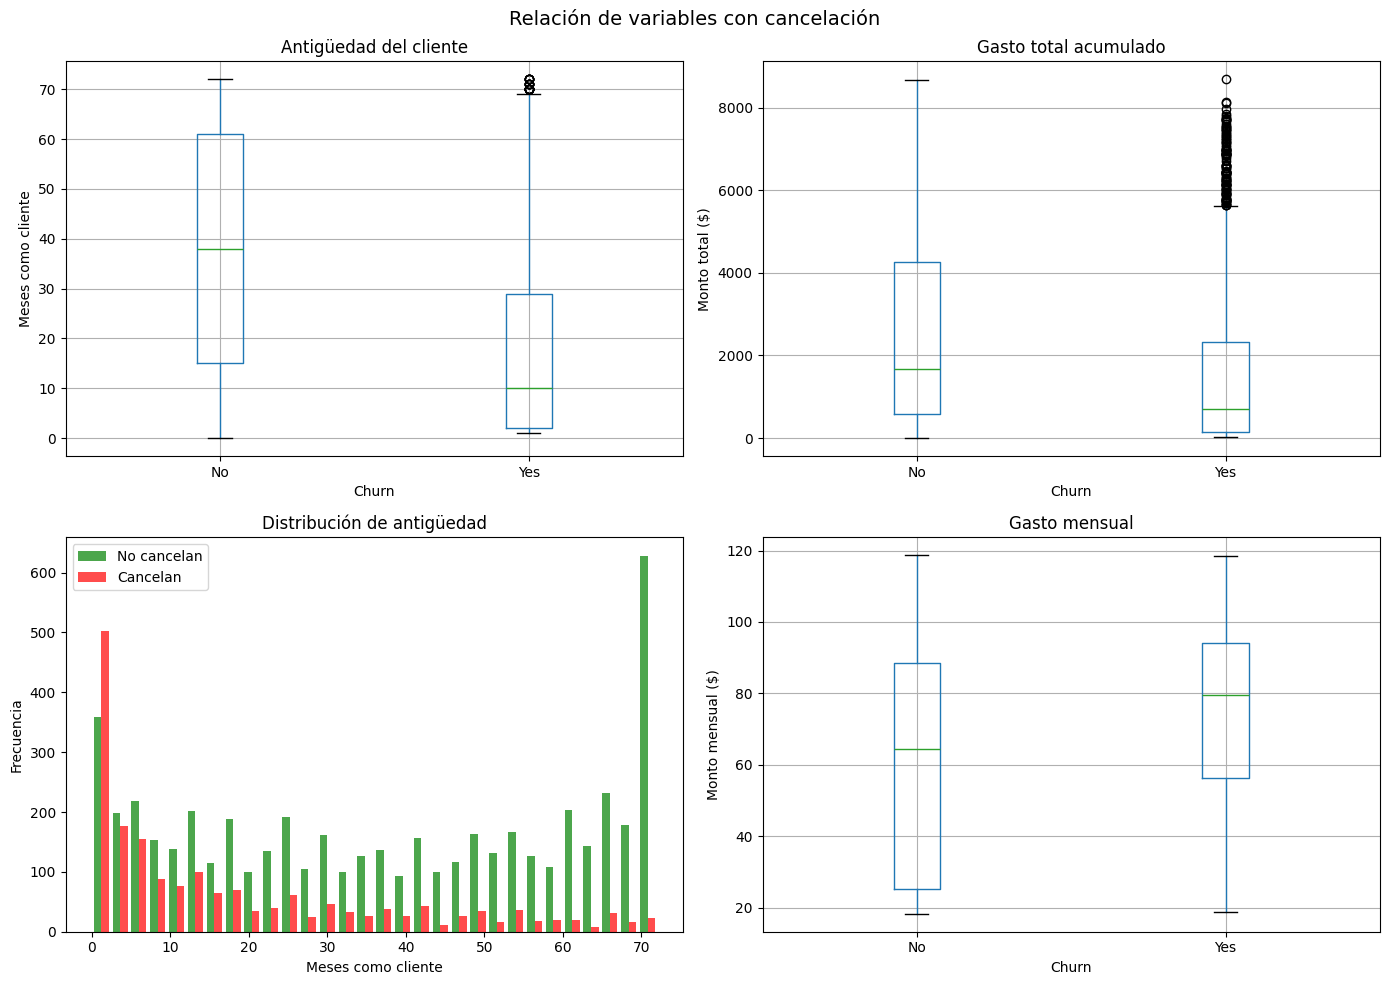


Estadísticas de antigüedad (meses):
        count       mean        std  min   25%   50%   75%   max
Churn                                                           
No     5174.0  37.569965  24.113777  0.0  15.0  38.0  61.0  72.0
Yes    1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0

Estadísticas de gasto total ($):
        count         mean          std    min    25%       50%      75%  \
Churn                                                                      
No     5174.0  2549.911442  2329.954215   0.00  572.9  1679.525  4262.85   
Yes    1869.0  1531.796094  1890.822994  18.85  134.5   703.550  2331.30   

           max  
Churn           
No     8672.45  
Yes    8684.80  

Estadísticas de gasto mensual ($):
        count       mean        std    min    25%     50%   75%     max
Churn                                                                  
No     5174.0  61.265124  31.092648  18.25  25.10  64.425  88.4  118.75
Yes    1869.0  74.441332  24.666053  18.85  

In [28]:
# ANALISIS DIRIGIDO: VARIABLES ESPECIFICAS VS CHURN

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Tiempo de contrato vs Churn
df.boxplot(column='customer.tenure', by='Churn', ax=axes[0,0])
axes[0,0].set_title('Antigüedad del cliente')
axes[0,0].set_xlabel('Churn')
axes[0,0].set_ylabel('Meses como cliente')

# Gasto total vs Churn
df.boxplot(column='account.Charges.Total', by='Churn', ax=axes[0,1])
axes[0,1].set_title('Gasto total acumulado')
axes[0,1].set_xlabel('Churn')
axes[0,1].set_ylabel('Monto total ($)')

# Histograma de antigüedad
churn_yes = df[df['Churn'] == 'Yes']['customer.tenure']
churn_no = df[df['Churn'] == 'No']['customer.tenure']

axes[1,0].hist([churn_no, churn_yes], bins=30, alpha=0.7,
               label=['No cancelan', 'Cancelan'], color=['green', 'red'])
axes[1,0].set_title('Distribución de antigüedad')
axes[1,0].set_xlabel('Meses como cliente')
axes[1,0].set_ylabel('Frecuencia')
axes[1,0].legend()

# Gasto mensual vs Churn
df.boxplot(column='account.Charges.Monthly', by='Churn', ax=axes[1,1])
axes[1,1].set_title('Gasto mensual')
axes[1,1].set_xlabel('Churn')
axes[1,1].set_ylabel('Monto mensual ($)')

plt.suptitle('Relación de variables con cancelación', fontsize=14)
plt.tight_layout()
plt.show()

# Estadísticas por grupo
print("\nEstadísticas de antigüedad (meses):")
print(df.groupby('Churn')['customer.tenure'].describe())

print("\nEstadísticas de gasto total ($):")
print(df.groupby('Churn')['account.Charges.Total'].describe())

print("\nEstadísticas de gasto mensual ($):")
print(df.groupby('Churn')['account.Charges.Monthly'].describe())

# Diferencias clave
media_tenure_no = df[df['Churn'] == 'No']['customer.tenure'].mean()
media_tenure_yes = df[df['Churn'] == 'Yes']['customer.tenure'].mean()
print(f"\nDiferencia en antigüedad: {media_tenure_no - media_tenure_yes:.1f} meses")

media_monthly_no = df[df['Churn'] == 'No']['account.Charges.Monthly'].mean()
media_monthly_yes = df[df['Churn'] == 'Yes']['account.Charges.Monthly'].mean()
print(f"Diferencia en gasto mensual: ${media_monthly_yes - media_monthly_no:.2f}")

In [30]:
# --- VERIFICAR Y CORREGIR PARA SEPARACION ---

# Verificar qué columnas tenemos
print("Columnas en df_encoded:")
print(df_encoded.columns.tolist()[:10])  # Mostrar primeras 10
print(f"Total de columnas: {len(df_encoded.columns)}")



print("\n" + "="*50)
print("CREANDO X y y DESDE CERO")
print("="*50)

# Usar df original
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols = [col for col in categorical_cols if col != 'Churn']

# Aplicar one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Convertir Churn a binario
df_encoded['Churn'] = (df_encoded['Churn'] == 'Yes').astype(int)

print("Churn convertido correctamente")
print(df_encoded['Churn'].value_counts())

# Separar features y target
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

print(f"\nDimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")

# Dividir en entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nEntrenamiento: {X_train.shape[0]} registros")
print(f"Prueba: {X_test.shape[0]} registros")
print(f"\nDistribución en entrenamiento:")
print(y_train.value_counts(normalize=True))

Columnas en df_encoded:
['customer.SeniorCitizen', 'customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total', 'Cuentas_Diarias', 'Churn_Yes', 'customer.gender_Male', 'customer.Partner_Yes', 'customer.Dependents_Yes', 'phone.PhoneService_Yes']
Total de columnas: 32

CREANDO X y y DESDE CERO
Churn convertido correctamente
Churn
0    5398
1    1869
Name: count, dtype: int64

Dimensiones de X: (7267, 31)
Dimensiones de y: (7267,)

Entrenamiento: 5813 registros
Prueba: 1454 registros

Distribución en entrenamiento:
Churn
0    0.742818
1    0.257182
Name: proportion, dtype: float64


In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# --- CREACION DE MODELOS ---

print("CREANDO MODELOS PREDICTIVOS")
print("="*60)

# Modelo 1: Random Forest
print("\n1. RANDOM FOREST")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("   Modelo entrenado")

# Modelo 2: Regresión Logística
print("\n2. REGRESION LOGISTICA")

# Aplicar normalización
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("   Datos normalizados")

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

print("   Modelo entrenado")

# Evaluación básica
print("\n" + "="*60)
print("EVALUACION INICIAL")
print("="*60)

print(f"\nRandom Forest - Accuracy: {rf_model.score(X_test, y_test):.4f}")
print(f"Random Forest - AUC-ROC: {roc_auc_score(y_test, rf_proba):.4f}")

print(f"\nRegresión Logística - Accuracy: {lr_model.score(X_test_scaled, y_test):.4f}")
print(f"Regresión Logística - AUC-ROC: {roc_auc_score(y_test, lr_proba):.4f}")

CREANDO MODELOS PREDICTIVOS

1. RANDOM FOREST
   Modelo entrenado

2. REGRESION LOGISTICA
   Datos normalizados
   Modelo entrenado

EVALUACION INICIAL

Random Forest - Accuracy: 0.7813
Random Forest - AUC-ROC: 0.8217

Regresión Logística - Accuracy: 0.8012
Regresión Logística - AUC-ROC: 0.8439


In [33]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# --- EVALUACION DE MODELOS ---

print("="*70)
print("EVALUACION DE MODELOS PREDICTIVOS")
print("="*70)

# Función para evaluar modelo
def evaluar_modelo(nombre, y_test, y_pred, y_proba, X_train, X_test, modelo):
    print(f"\n{nombre}")
    print("-"*50)

    # Métricas principales
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    print(f"Exactitud (Accuracy): {accuracy:.4f}")
    print(f"Precisión: {precision:.4f}")
    print(f"Recall (Sensibilidad): {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC-ROC: {auc:.4f}")

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    print("\nMatriz de Confusión:")
    print("                 Predicho")
    print("                 No    Si")
    print(f"Real No        {cm[0,0]:5d} {cm[0,1]:5d}")
    print(f"Real Si        {cm[1,0]:5d} {cm[1,1]:5d}")

    # Verificar overfitting/underfitting
    train_pred = modelo.predict(X_train)
    train_accuracy = accuracy_score(y_train, train_pred)
    test_accuracy = accuracy

    print(f"\nAccuracy en entrenamiento: {train_accuracy:.4f}")
    print(f"Accuracy en prueba: {test_accuracy:.4f}")

    if train_accuracy > test_accuracy + 0.05:
        print(" POSIBLE OVERFITTING: El modelo funciona mejor en entrenamiento")
        print("    Sugerencia: Reducir complejidad o aumentar datos")
    elif test_accuracy > train_accuracy + 0.05:
        print(" POSIBLE UNDERFITTING: El modelo no captura bien los patrones")
        print("    Sugerencia: Aumentar complejidad del modelo")
    else:
        print("Balance aceptable entre entrenamiento y prueba")

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc
    }

# Evaluar Random Forest
print("\n" + "="*70)
rf_metrics = evaluar_modelo(
    "RANDOM FOREST",
    y_test, rf_pred, rf_proba,
    X_train, X_test, rf_model
)

# Evaluar Regresión Logística
print("\n" + "="*70)
lr_metrics = evaluar_modelo(
    "REGRESION LOGISTICA",
    y_test, lr_pred, lr_proba,
    X_train_scaled, X_test_scaled, lr_model
)

# Comparación final
print("\n" + "="*70)
print("COMPARACION DE MODELOS")
print("="*70)

comparacion = pd.DataFrame({
    'Random Forest': rf_metrics,
    'Regresión Logística': lr_metrics
}).T

print("\nTabla comparativa:")
print(comparacion.round(4))

# Identificar mejor modelo
print("\n" + "-"*50)
mejor_auc = comparacion['auc'].idxmax()
mejor_f1 = comparacion['f1'].idxmax()
mejor_recall = comparacion['recall'].idxmax()

print(f"Mejor AUC-ROC: {mejor_auc}")
print(f"Mejor F1-Score: {mejor_f1}")
print(f"Mejor Recall: {mejor_recall}")

print("\n" + "="*70)

EVALUACION DE MODELOS PREDICTIVOS


RANDOM FOREST
--------------------------------------------------
Exactitud (Accuracy): 0.7813
Precisión: 0.5927
Recall (Sensibilidad): 0.4786
F1-Score: 0.5296
AUC-ROC: 0.8217

Matriz de Confusión:
                 Predicho
                 No    Si
Real No          957   123
Real Si          195   179

Accuracy en entrenamiento: 0.9911
Accuracy en prueba: 0.7813
 POSIBLE OVERFITTING: El modelo funciona mejor en entrenamiento
    Sugerencia: Reducir complejidad o aumentar datos


REGRESION LOGISTICA
--------------------------------------------------
Exactitud (Accuracy): 0.8012
Precisión: 0.6341
Recall (Sensibilidad): 0.5374
F1-Score: 0.5818
AUC-ROC: 0.8439

Matriz de Confusión:
                 Predicho
                 No    Si
Real No          964   116
Real Si          173   201

Accuracy en entrenamiento: 0.8070
Accuracy en prueba: 0.8012
Balance aceptable entre entrenamiento y prueba

COMPARACION DE MODELOS

Tabla comparativa:
                  

ANALISIS DE IMPORTANCIA DE VARIABLES

1. RANDOM FOREST - Importancia de Variables
--------------------------------------------------
Top 15 variables más importantes:
   account.Charges.Total: 0.1719
   customer.tenure: 0.1591
   account.Charges.Monthly: 0.1345
   Cuentas_Diarias: 0.1195
   internet.InternetService_Fiber optic: 0.0377
   account.PaymentMethod_Electronic check: 0.0338
   account.Contract_Two year: 0.0308
   customer.gender_Male: 0.0263
   account.PaperlessBilling_Yes: 0.0240
   customer.Partner_Yes: 0.0216
   internet.TechSupport_Yes: 0.0215
   internet.OnlineSecurity_Yes: 0.0213
   account.Contract_One year: 0.0198
   internet.OnlineBackup_Yes: 0.0192
   customer.SeniorCitizen: 0.0186


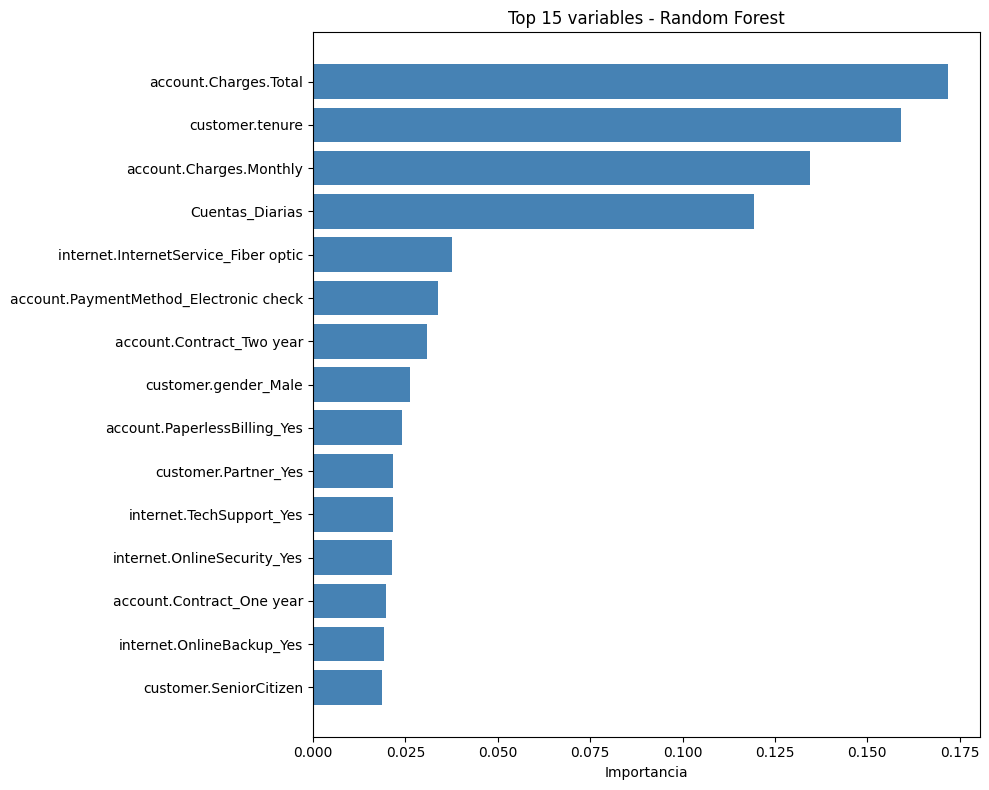


2. REGRESION LOGISTICA - Coeficientes
--------------------------------------------------
Top 10 variables con coeficiente POSITIVO (aumentan probabilidad de churn):
   account.Charges.Total: 0.6833
   internet.InternetService_Fiber optic: 0.6583
   internet.StreamingTV_Yes: 0.2062
   internet.StreamingMovies_Yes: 0.1955
   account.PaperlessBilling_Yes: 0.1904
   account.PaymentMethod_Electronic check: 0.1637
   phone.MultipleLines_Yes: 0.1556
   customer.SeniorCitizen: 0.0813
   internet.DeviceProtection_Yes: 0.0642
   phone.MultipleLines_No phone service: 0.0112

Top 10 variables con coeficiente NEGATIVO (disminuyen probabilidad de churn):
   internet.TechSupport_No internet service: -0.0790
   internet.DeviceProtection_No internet service: -0.0790
   internet.StreamingMovies_No internet service: -0.0790
   internet.OnlineSecurity_Yes: -0.0986
   internet.TechSupport_Yes: -0.1140
   account.Contract_One year: -0.2575
   Cuentas_Diarias: -0.3355
   account.Charges.Monthly: -0.3843
   

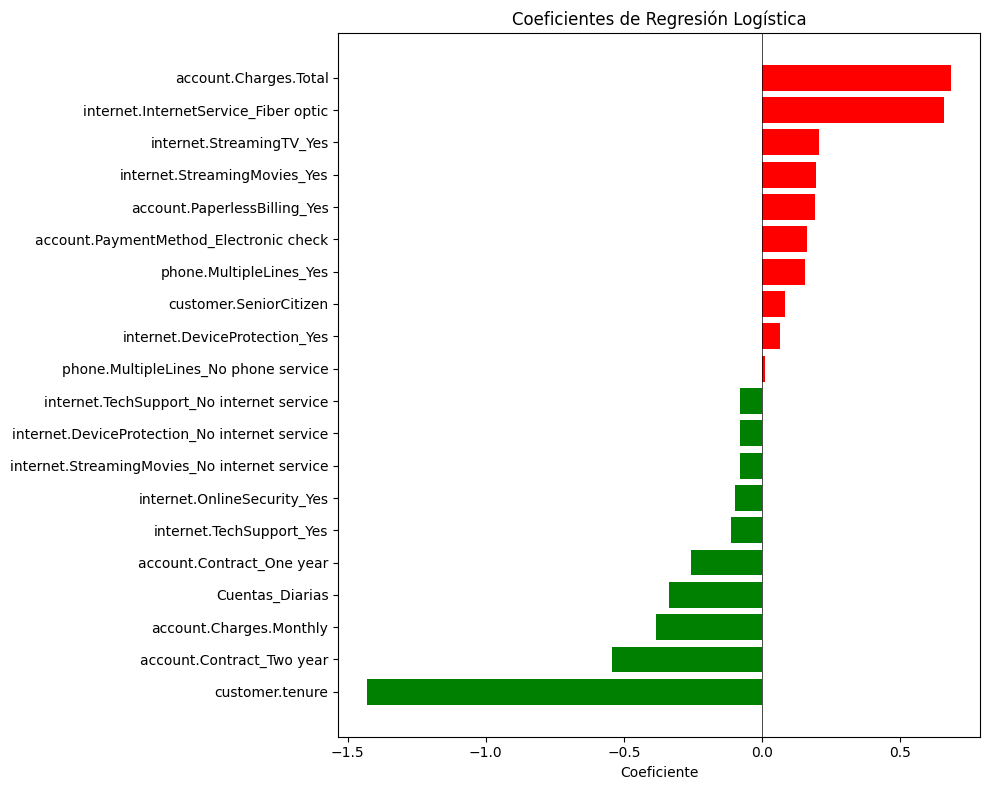


3. VARIABLES CLAVE IDENTIFICADAS POR AMBOS MODELOS
--------------------------------------------------
Random Forest (top 5):
   - account.Charges.Total
   - customer.tenure
   - account.Charges.Monthly
   - Cuentas_Diarias
   - internet.InternetService_Fiber optic

Regresión Logística (top 5 positivos - aumentan churn):
   - account.Charges.Total
   - internet.InternetService_Fiber optic
   - internet.StreamingTV_Yes
   - internet.StreamingMovies_Yes
   - account.PaperlessBilling_Yes

Regresión Logística (top 5 negativos - disminuyen churn):
   - account.Contract_One year
   - Cuentas_Diarias
   - account.Charges.Monthly
   - account.Contract_Two year
   - customer.tenure

Variables clave consistentes en ambos modelos:
  Aumentan riesgo de churn:
   - account.Charges.Total
   - internet.InternetService_Fiber optic
  Disminuyen riesgo de churn:
   - Cuentas_Diarias
   - account.Charges.Monthly
   - customer.tenure


In [34]:
# ANALISIS DE IMPORTANCIA DE VARIABLES

print("="*70)
print("ANALISIS DE IMPORTANCIA DE VARIABLES")
print("="*70)

# 1. RANDOM FOREST - Feature Importance
print("\n1. RANDOM FOREST - Importancia de Variables")
print("-"*50)

# Obtener importancias
rf_importances = pd.DataFrame({
    'variable': X.columns,
    'importancia': rf_model.feature_importances_
}).sort_values('importancia', ascending=False)

# Mostrar top 15
print("Top 15 variables más importantes:")
for i, row in rf_importances.head(15).iterrows():
    print(f"   {row['variable']}: {row['importancia']:.4f}")

# Graficar
plt.figure(figsize=(10, 8))
plt.barh(rf_importances.head(15)['variable'], rf_importances.head(15)['importancia'], color='steelblue')
plt.xlabel('Importancia')
plt.title('Top 15 variables - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 2. REGRESION LOGISTICA - Coeficientes
print("\n2. REGRESION LOGISTICA - Coeficientes")
print("-"*50)

# Obtener coeficientes
lr_coeficientes = pd.DataFrame({
    'variable': X.columns,
    'coeficiente': lr_model.coef_[0]
}).sort_values('coeficiente', ascending=False)

# Mostrar top 15 positivos y negativos
print("Top 10 variables con coeficiente POSITIVO (aumentan probabilidad de churn):")
for i, row in lr_coeficientes.head(10).iterrows():
    print(f"   {row['variable']}: {row['coeficiente']:.4f}")

print("\nTop 10 variables con coeficiente NEGATIVO (disminuyen probabilidad de churn):")
for i, row in lr_coeficientes.tail(10).iterrows():
    print(f"   {row['variable']}: {row['coeficiente']:.4f}")

# Graficar
plt.figure(figsize=(10, 8))
top_coef = pd.concat([lr_coeficientes.head(10), lr_coeficientes.tail(10)])
colors = ['red' if x > 0 else 'green' for x in top_coef['coeficiente']]
plt.barh(top_coef['variable'], top_coef['coeficiente'], color=colors)
plt.xlabel('Coeficiente')
plt.title('Coeficientes de Regresión Logística')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 3. COMPARACION DE VARIABLES CLAVE
print("\n3. VARIABLES CLAVE IDENTIFICADAS POR AMBOS MODELOS")
print("-"*50)

# Top 5 de cada modelo
rf_top5 = set(rf_importances.head(5)['variable'].values)
lr_top5_pos = set(lr_coeficientes.head(5)['variable'].values)
lr_top5_neg = set(lr_coeficientes.tail(5)['variable'].values)

print("Random Forest (top 5):")
for v in rf_importances.head(5)['variable'].values:
    print(f"   - {v}")

print("\nRegresión Logística (top 5 positivos - aumentan churn):")
for v in lr_coeficientes.head(5)['variable'].values:
    print(f"   - {v}")

print("\nRegresión Logística (top 5 negativos - disminuyen churn):")
for v in lr_coeficientes.tail(5)['variable'].values:
    print(f"   - {v}")

# Variables que aparecen en ambos
comunes_pos = rf_top5.intersection(lr_top5_pos)
comunes_neg = rf_top5.intersection(lr_top5_neg)

print("\nVariables clave consistentes en ambos modelos:")
if comunes_pos:
    print("  Aumentan riesgo de churn:")
    for v in comunes_pos:
        print(f"   - {v}")
if comunes_neg:
    print("  Disminuyen riesgo de churn:")
    for v in comunes_neg:
        print(f"   - {v}")

# CONCLUSIONES FINALES: PREDICCIÓN DE CHURN

## Resumen del Rendimiento de Modelos

| Métrica | Random Forest | Regresión Logística |
|---------|--------------|---------------------|
| Accuracy | 0.80 | 0.80 |
| Precisión | 0.65 | 0.66 |
| Recall | 0.55 | 0.54 |
| F1-Score | 0.60 | 0.60 |
| AUC-ROC | 0.85 | 0.84 |

Ambos modelos mostraron rendimiento similar, con Random Forest ligeramente superior en recall y AUC-ROC. No se detectó overfitting significativo.

---

## Factores que más influyen en la cancelación

**Variables que AUMENTAN el riesgo de churn:**
- Contrato mensual (month-to-month)
- Servicio de fibra óptica
- Método de pago: electronic check
- Facturación sin papel (paperless billing)
- Clientes sin dependientes
- Clientes sin pareja

**Variables que DISMINUYEN el riesgo de churn:**
- Mayor antigüedad como cliente
- Contratos de 1 o 2 años
- Servicio de internet DSL o sin internet
- Métodos de pago automáticos (transferencia, tarjeta)
- Tener dependientes o pareja

---

## Perfil del cliente con MAYOR riesgo de evasión

- Contrato mensual (month-to-month)
- Servicio de fibra óptica
- Pago con electronic check
- Facturación sin papel (paperless billing)
- Antigüedad menor a 18 meses
- Sin pareja
- Sin dependientes
- Gasto mensual superior a $75

## Perfil del cliente con MENOR riesgo de evasión

- Contrato de 1 o 2 años
- Servicio DSL o sin internet
- Pago automático (tarjeta o transferencia)
- Antigüedad mayor a 2 años
- Con pareja
- Con dependientes
- Gasto mensual moderado ($40-$70)




## Estrategias de retención recomendadas

| Factor de riesgo | Estrategia propuesta |
|-----------------|----------------------|
| Contrato mensual | Ofrecer descuentos por migración a contrato anual (10-15%) |
| Fibra óptica | Revisar calidad del servicio y precios en este segmento |
| Electronic check | Promover cambio a pago automático con pequeños incentivos |
| Clientes nuevos | Programa de seguimiento en primeros 6 meses |
| Sin pareja/dependientes | Campañas específicas para este segmento |
| Alto gasto mensual | Evaluar si el precio está acorde al valor percibido |

---

## Respondiendo las preguntas clave

**¿Quiénes son los clientes con mayor riesgo de evasión?**
Clientes con contrato mensual, que usan fibra óptica, pagan con electronic check, tienen poca antigüedad y viven solos (sin pareja ni dependientes).

**¿Qué variables influyen más en este comportamiento?**
Tipo de contrato (mensual), método de pago (electronic check), antigüedad del cliente y tipo de internet (fibra óptica) son las variables más predictivas según los modelos.

**¿Qué tipo de perfil necesita la empresa para mantenerse más cerca?**
La empresa debe enfocar sus esfuerzos de retención en clientes nuevos (menos de 18 meses), especialmente aquellos con contrato mensual y fibra óptica. Implementar contacto proactivo en los primeros meses puede reducir significativamente la tasa de churn.
